# Gradient Descent — Optimization from Scratch

This notebook demonstrates gradient descent as a core optimization method in machine learning.

The first example applies gradient descent to a simple one-dimensional convex function. The second example uses gradient descent to fit a linear regression model.

## Goals

Walk through the core ideas of gradient descent:

- Define a loss function
- Compute the gradient
- Update parameters in the negative gradient direction
- Visualize the optimization path
- Compare different learning rates
- Use gradient descent to fit linear regression

Evaluate gradient descent using:

- Loss over iterations
- Convergence behavior
- Effect of learning rate
- Comparison between gradient descent and the closed-form least-squares solution

Interpret how the learning rate affects whether gradient descent converges slowly, quickly, oscillates, or diverges.

## Example 1

- Function: `f(x) = (x - 3)^2`
- True minimum: `x = 3`
- Starting point: `x = 10`
- Goal: show how gradient descent moves toward the minimum

## Example 2

- Synthetic linear regression data
- True relationship: approximately `y = 2x + 1 + noise`
- Goal: show that gradient descent can recover a fitted line similar to the closed-form solution

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
np.random.seed(42)

## 1. GD on a 1-D convex function

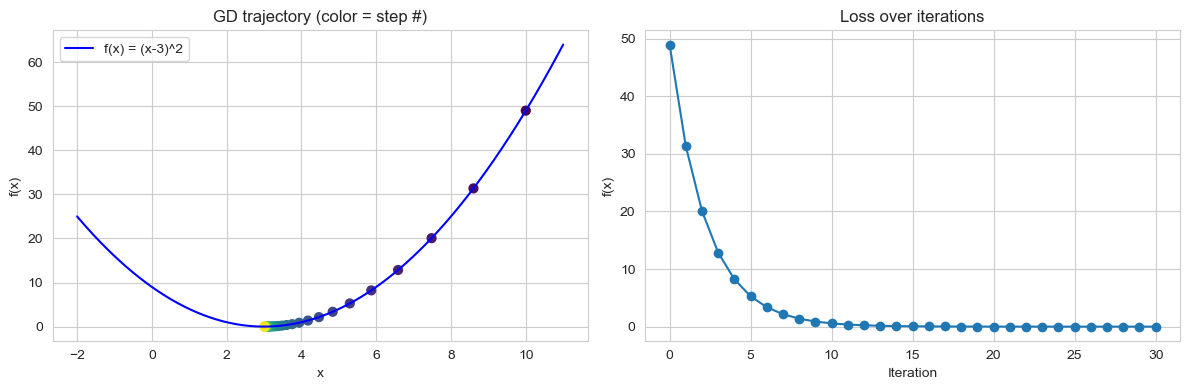

Converged to x = 3.0087 (true min: x=3)


In [2]:
def f(x):
    return (x - 3) ** 2


def grad(x):
    return 2 * (x - 3)


# Gradient descent: x_{t+1} = x_t - lr * gradient(x_t)
# Start far from the minimum (x=10) and watch x converge to 3 (the actual minimum)
xs = [10.0]
lr = 0.1                                       # learning rate (step size)
for _ in range(30):
    xs.append(xs[-1] - lr * grad(xs[-1]))      # one GD step

xs = np.array(xs)

xx = np.linspace(-2, 11, 300)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(xx, f(xx), "b-", label="f(x) = (x-3)^2")
ax[0].scatter(xs, f(xs), c=np.arange(len(xs)), cmap="viridis", s=40)
ax[0].set_xlabel("x")
ax[0].set_ylabel("f(x)")
ax[0].set_title("GD trajectory (color = step #)")
ax[0].legend()

ax[1].plot(f(xs), marker="o")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("f(x)")
ax[1].set_title("Loss over iterations")

plt.tight_layout()
plt.show()

print(f"Converged to x = {xs[-1]:.4f} (true min: x=3)")

## 2. Effect of learning rate

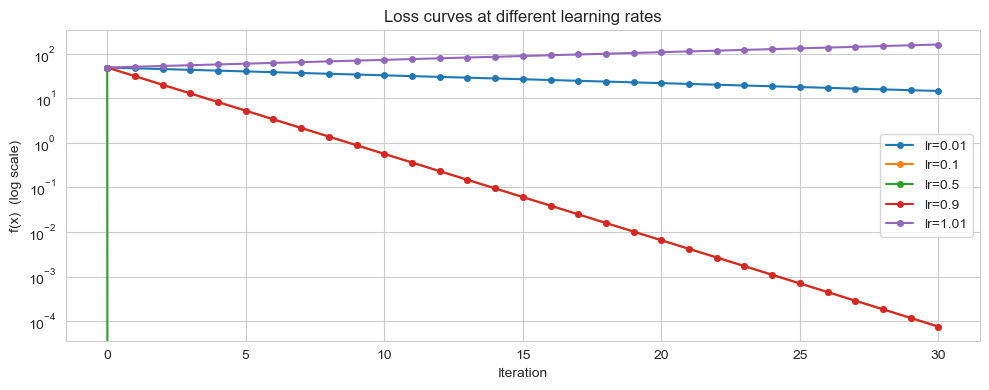

In [3]:
def gd(lr, n=30, x0=10.0):
    xs = [x0]
    for _ in range(n):
        xs.append(xs[-1] - lr * grad(xs[-1]))
    return np.array(xs)

plt.figure(figsize=(10, 4))

for lr in [0.01, 0.1, 0.5, 0.9, 1.01]:
    plt.plot(f(gd(lr)), label=f"lr={lr}", marker="o", ms=4)

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("f(x)  (log scale)")
plt.title("Loss curves at different learning rates")
plt.legend()
plt.tight_layout()
plt.show()

With **lr = 1.01**, gradient descent diverges because the step size is too large and overshoots the minimum more each iteration. **lr = 0.5** jumps directly to the minimum for this specific quadratic example. **lr = 0.9** still converges but oscillates around the minimum. Smaller learning rates are slower but stable. This illustrates one of the most important hyperparameter trade-offs in machine learning.

## 3. Linear regression by gradient descent

In [4]:
# Synthetic data: y = 2x + 1 + noise
N = 100

X = np.linspace(0, 10, N).reshape(-1, 1)
y = 2 * X.ravel() + 1 + np.random.normal(scale=1.5, size=N)

# Closed-form (normal equations) solution
X_aug = np.hstack([np.ones((N, 1)), X])

theta_closed = np.linalg.lstsq(X_aug, y, rcond=None)[0]

print(f"Closed-form: intercept={theta_closed[0]:.4f}, slope={theta_closed[1]:.4f}")

Closed-form: intercept=0.7408, slope=2.0207


In [5]:
# Gradient descent from scratch
def lr_loss(theta, X, y):
    return ((X @ theta - y) ** 2).mean()


def lr_grad(theta, X, y):
    return 2 * X.T @ (X @ theta - y) / len(y)


# This scales to massive datasets where the closed form is intractable.
theta = np.zeros(2)              # initialize parameters at zero
lr = 0.01                        # learning rate — small enough to be stable
losses = []
for _ in range(2000):            # 2000 iterations is overkill but cheap
    theta = theta - lr * lr_grad(theta, X_aug, y)
    losses.append(lr_loss(theta, X_aug, y))

print(f"GD result:    intercept={theta[0]:.4f}, slope={theta[1]:.4f}")

GD result:    intercept=0.7408, slope=2.0207


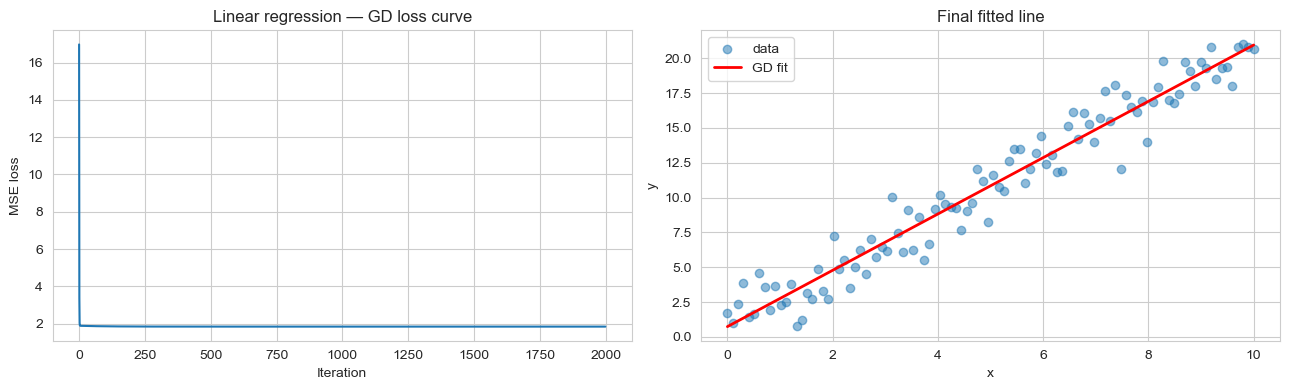

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(losses)
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("MSE loss")
ax[0].set_title("Linear regression — GD loss curve")

ax[1].scatter(X, y, alpha=0.5, label="data")

xs = np.array([0, 10])

ax[1].plot(xs, theta[0] + theta[1] * xs, "r-", lw=2, label="GD fit")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[1].legend()
ax[1].set_title("Final fitted line")

plt.tight_layout()
plt.show()

## Takeaways

- Gradient descent is a general optimization method used throughout machine learning. The basic idea is: choose a loss function, compute its gradient, and repeatedly step in the negative gradient direction.

- In the 1-D example, gradient descent converges close to the true minimum: `x = 3.0087`, while the true minimum is `x = 3`.

- The learning rate is critical. If it is too small, convergence is slow; if it is too large, gradient descent can overshoot and diverge. In this notebook, `lr = 1.01` diverges, while smaller learning rates remain stable.

- For linear regression, gradient descent reaches the same solution as the closed-form least-squares method. Both produce an intercept of about `0.7408` and a slope of about `2.0207`.

- Gradient descent is especially useful because it scales to problems where closed-form solutions are impractical, such as very large datasets and neural networks.

- Common variants include stochastic gradient descent, mini-batch gradient descent, momentum, and Adam.